# 快速验证
这个demo主要提供部分样板代码，方便快速验证新知识点

## 修改历史
验证涉及的新知识点记录在这里，作为备忘

- StateSchema的每一个属性都是channel，通道会依据metadata中指定的归约器进行状态更新
- channel的默认（即不指定归约器）行为是 覆盖 ，即新值覆盖旧值
- 使用operator.add作为归约器时，如果是list，会把所有并行节点的计算结果追加到list末尾，如果是数字类型，那么会依次对每个节点的返回值做add
- Annotated是py的预置类型，为已有类型添加元数据，langgraph用它来指定归约器
- 自定义reducer可以定制符合业务规则的归约逻辑；尽量保持幂等性；自定义reducer可以根据业务需要实现不同的合并策略；同样可以
- list(set(list_a, list_b))可以实现去重合并
- RemoveMessage是langchain_core暴露的MessagesState操作函数，用于删除指定id的消息


### py知识点
- list[-n:] : 保留最新的n个元素,如果不带:，表示读取从后往前的第n个元素
- {**args1, **args2}: 深度合并两个字典，同名元素会覆盖



## Error

Error:  InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
Reason: 使用默认归约器的覆盖规则，但是出现节点并行更新，导致更新冲突，不知道该保留哪一个

In [1]:
# 创建glm4.7的客户端实例，一般不用改
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)



[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


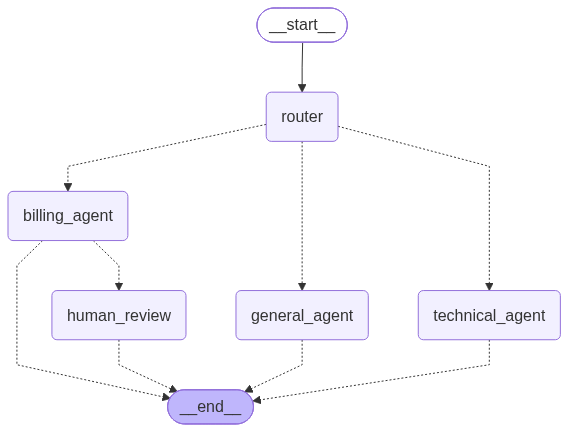

In [3]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command, interrupt
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
from pydantic import BaseModel

# 定义状态
class CustomerServiceState(TypedDict):
    messages: Annotated[list, add_messages]
    customer_issue: str
    issue_category: str | None
    resolution: str | None

# 定义路由决策模型
class IssueClassification(BaseModel):
    category: Literal["billing", "technical", "general"]
    urgency: Literal["low", "medium", "high"]
    reason: str

# 路由 Agent
def router_agent(state: CustomerServiceState) -> Command[Literal["billing_agent", "technical_agent", "general_agent"]]:
    """分析客户问题，路由到正确的专业 Agent"""

    classifier = llm.with_structured_output(IssueClassification)

    classification = classifier.invoke([
        SystemMessage("分析客户问题，确定类别和紧急程度"),
        HumanMessage(state["customer_issue"])
    ])

    agent_map = {
        "billing": "billing_agent",
        "technical": "technical_agent",
        "general": "general_agent"
    }

    return Command(
        update={
            "issue_category": classification.category,
            "messages": [AIMessage(content=f"问题分类：{classification.category}，原因：{classification.reason}")]
        },
        goto=agent_map[classification.category]
    )

# 账单 Agent
def billing_agent(state: CustomerServiceState) -> Command[Literal["human_review", END]]:
    """处理账单相关问题"""

    response = llm.invoke([
        SystemMessage("你是账单专家，处理客户的账单问题"),
        *state["messages"],
        HumanMessage(state["customer_issue"])
    ])

    # 涉及退款需要人工审核
    if "退款" in response.content or "refund" in response.content.lower():
        return Command(
            update={"messages": [response], "resolution": response.content},
            goto="human_review"
        )

    return Command(
        update={"messages": [response], "resolution": response.content},
        goto=END
    )

# 技术支持 Agent
def technical_agent(state: CustomerServiceState) -> Command[Literal[END]]:
    """处理技术问题"""

    response = llm.invoke([
        SystemMessage("你是技术支持专家，帮助客户解决技术问题"),
        *state["messages"],
        HumanMessage(state["customer_issue"])
    ])

    return Command(
        update={"messages": [response], "resolution": response.content},
        goto=END
    )

# 通用 Agent
def general_agent(state: CustomerServiceState) -> Command[Literal[END]]:
    """处理一般性咨询"""

    response = llm.invoke([
        SystemMessage("你是客服代表，处理一般性咨询"),
        *state["messages"],
        HumanMessage(state["customer_issue"])
    ])

    return Command(
        update={"messages": [response], "resolution": response.content},
        goto=END
    )

# 人工审核节点
def human_review(state: CustomerServiceState) -> Command[Literal[END]]:
    """需要人工审核的情况"""

    # 暂停等待人工输入
    approval = interrupt({
        "question": "请审核以下退款请求",
        "resolution": state["resolution"],
        "customer_issue": state["customer_issue"]
    })

    if approval == "approved":
        final_response = f"您的请求已批准。{state['resolution']}"
    else:
        final_response = "抱歉，您的请求需要进一步处理，我们会尽快联系您。"

    return Command(
        update={
            "messages": [AIMessage(content=final_response)],
            "resolution": final_response
        },
        goto=END
    )

# 构建图
def build_customer_service_graph():
    graph = StateGraph(CustomerServiceState)

    # 添加节点
    graph.add_node("router", router_agent)
    graph.add_node("billing_agent", billing_agent)
    graph.add_node("technical_agent", technical_agent)
    graph.add_node("general_agent", general_agent)
    graph.add_node("human_review", human_review)

    # 只需要添加入口边
    graph.add_edge(START, "router")
    # 其他路由由 Command 处理，不需要显式添加边！

    return graph.compile()

# 使用
app = build_customer_service_graph()

from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))


In [4]:
# 测试
result = app.invoke({
    "customer_issue": "我上个月的账单多收了 50 块钱，我要求退款",
    "messages": []
})

print(result["resolution"])

ValidationError: 1 validation error for IssueClassification
  Invalid JSON: expected value at line 1 column 1 [type=json_invalid, input_value='以下是针对您提供...得到妥善解决。', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid